# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**:

**ID**:

> **Due Date**
>
> Thursday, 11/07/23, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 2 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.
-   Problem 3 (5750 only) asks you to add a CO<sub>2</sub> constraint to
    the capacity expansion problem and identify changes in the resulting
    solution.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Documents/Programming/Julia/BEE4750/hw/hw4-jiaming-ari-grace`


In [3]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables

## Problems (Total: 50/60 Points)

### Problem 1 (20 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/ha-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

**In this problem**:

-   Formulate a linear program for this resource allocation problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations). **Tip: Make sure that all of your constraints are
    linear**.
-   Implement the program in `JuMP.jl` and find the solution. How many
    ha should the farmer dedicate to each crop and with what pesticide
    application rate(s)? How much profit will the farmer expect to make?
-   The farmer has an opportunity to buy an extra 10 ha of land. How
    much extra profit would this land be worth to the farmer? Discuss
    why this value makes sense and whether you would recommend the
    farmer should make the purchase.


In [ ]:
function crop_model(land_area)
    crop_model = Model(HiGHS.Optimizer) #initialize model object
    @variable(crop_model, A[1:9] >= 0) #area covered by crop with 0, 1, or 2 kg/ha pesticide [S0, S1, S2, W0, W1, W2, C0, C1, C2]
     @objective(crop_model, Max, 694*A[1] + 948*A[2] + 1234*A[3] + 525*A[4] + 757*A[5] + 854*A[6] + 768*A[7] + 1014*A[8] + 1348*A[9]) #equation for profit
     @constraint(crop_model, S_maxpest, (A[2] + 2*A[3]) <= 0.8*(A[1]+A[2]+A[3]))
     @constraint(crop_model, W_maxpest, (A[5] + 2*A[6]) <= 0.7*(A[4]+A[5]+A[6]))
     @constraint(crop_model, C_maxpest, (A[8] + 2*A[9]) <= 0.6*(A[7]+A[8]+A[9]))
     @constraint(crop_model, total_area, (A[1] + A[2] + A[3] + A[4] + A[5] + A[6] + A[7] + A[8] + A[9]) <= land_area)
     @constraint(crop_model, S_demand, (2900*A[1] + 3800*A[2] + 4400*A[3]) <= 250000)
     @constraint(crop_model, W_demand, (3500*A[4] + 4100*A[5] + 4200*A[6]) <= 250000)
     @constraint(crop_model, C_demand, (5900*A[7] + 6700*A[8] + 7900*A[9]) <= 250000)
     optimize!(crop_model)
    return value.(A)
end

In [ ]:
Dist_130ha, profit_130 = crop_model(130)
print(Dist_130ha)
Dist_140ha, profit_140 = crop_model(140)
print(Dist_140ha)

### Problem 1 Writeup

For 130 ha, the farmer should follow this distribution of crops and pesticides:
| Application Rate (kg/ha) |     Soybean (ha)     |      Wheat (ha)      |       Corn (ha)      |
|:------------------------:|:--------------------:|:--------------------:|:--------------------:|
|            0             |  42.857142857142854  |   6.032967032967031  |  26.923076923076938  |
|            1             |          0.0         |  14.076923076923077  |          0.0         |
|            2             |   28.57142857142857  |          0.0         |  11.538461538461533  |

and for 140 ha, the farmer should follow this distribution of crops and pesticides:
| Application Rate (kg/ha) |     Soybean (ha)     |      Wheat (ha)      |       Corn (ha)      |
|:------------------------:|:--------------------:|:--------------------:|:--------------------:|
|            0             |  42.857142857142854  |   9.032967032967036  |  26.923076923076938  |
|            1             |          0.0         |  21.076923076923066  |          0.0         |
|            2             |   28.57142857142857  |          0.0         |  11.538461538461533  |

The profit for $130$ ha total is $115,054.31$ dollars and the profit for $140$ ha total is $121,928.31$ dollars, so he will increase his profits by $6,874.00$ dollars if he buys the extra $10$ ha of land. Therefore, I would only suggest that he buy that land if the cost of the plot of land is less than this increased profit.

In order to solve this problem, we have to define our decision variables as the area, in hectares, that we will plant with soybeans, wheat, and corn with each quantity of pesticide. In other words, the array of values $[S_0, S_1, S_2, W_0, W_1, W_2, C_0, C_1, C_2]$, where, for example $S_0$ represents the area that has no pesticide applied and is planted with soybeans. Then, we have to define an equation to maximize in order to create our objective which is to make the most profit where $Profit = Revenue - Cost$. To do this, we can first calculate the total revenue. We are given the selling price per kilogram of each crop, so to get the total revenue, we need to calculate the total 


### Problem 2 (30 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

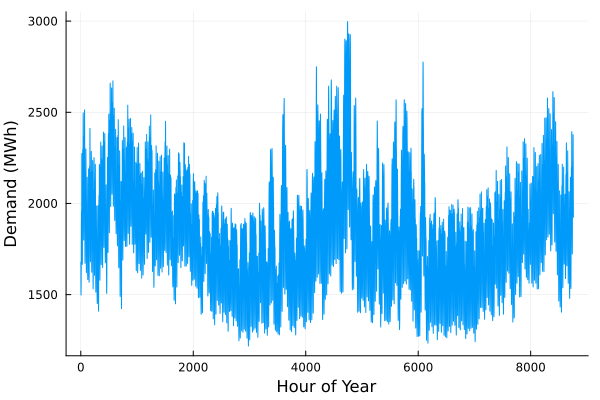

In [4]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [5]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

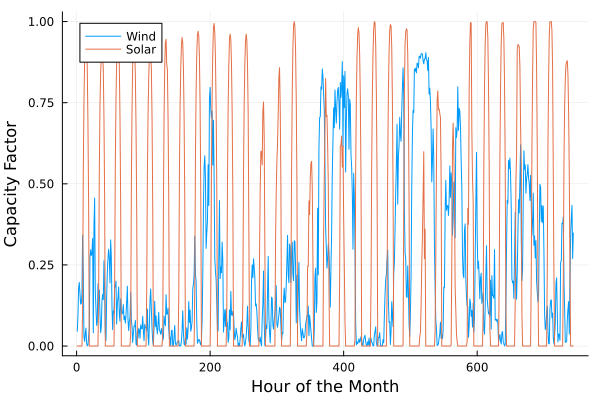

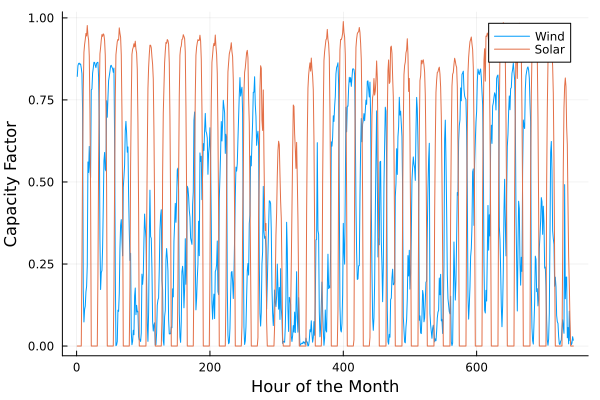

In [6]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

**In this problem**:

-   Formulate a linear program for this capacity expansion problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations).
-   Implement your linear program in `JuMP.jl`. Find the optimal
    solution. How much should the utility build of each type of
    generating plant? What will the total cost be? How much energy will
    be non-served?
-   What fraction of annual generation does each plant type produce? How
    does this compare to the breakdown of built capacity that you found
    in Problem 1.5? Do these results make sense given the generator
    data?
-   Make a plot of the electricity price in each hour. Discuss any
    trends that you see.

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

In [7]:
# define sets
G = 1:nrow(gens)
T = 1:nrow(demand)
NSECost = 10000

gencap = Model(HiGHS.Optimizer)
# define variables
@variables(gencap, begin
    x[g in G] >= 0
    y[g in G, t in T] >= 0
    NSE[t in T] >= 0
end)
@objective(gencap, Min, 
    sum(gens[G, :FixedCost] .* x) + sum(gens[G, :VarCost] .* sum(y[:, t] for t in T)) + NSECost * sum(NSE)
)
@constraint(gencap, load[t in T], sum(y[:, t]) + NSE[t] >= demand.Demand[t]);
@constraint(gencap, availability[g in G, t in T], y[g, t] <= x[g]);
@constraint(gencap, geo[g in G], x[1] <= 0.85*x[1]);
@constraint(gencap, solar[g in G, t in T], y[5,t] <= cap_factor.Solar[t]*x[5]);
@constraint(gencap, wind[g in G, t in T], y[6,t] <= cap_factor.Wind[t]*x[6]);
optimize!(gencap);

Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 3e+03]
Presolving model
139656 rows, 56861 cols, 305424 nonzeros  0s
61120 rows, 48101 cols, 152816 nonzeros  0s
61120 rows, 48101 cols, 152816 nonzeros  0s
Presolve : Reductions: rows 61120(-105326); columns 48101(-13225); elements 152816(-197086)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.14654e+06) 0s
      36021     6.5136464912e+08 Pr: 0(0); Du: 0(6.23305e-11) 4s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 36021
Objective value     :  6.5136464912e+08
HiGHS run time      :          4.33


In [8]:
@show value.(x[G]).data #this is the amount of each type to build

value.(x[G]).data = [0.0, 0.0, 1563.4374788598068, 900.0013676000301, 576.6272201360977, 2042.5741988632253]


6-element Vector{Float64}:
    0.0
    0.0
 1563.4374788598068
  900.0013676000301
  576.6272201360977
 2042.5741988632253

In [9]:
@show round(objective_value.(gencap), sigdigits = 5) #total cost


round(objective_value.(gencap), sigdigits = 5) = 6.5136e8


6.5136e8

In [10]:
@show sum(value.(NSE)) #total nonserved energy

sum(value.(NSE)) = 349.9888962085038


349.9888962085038

In [11]:
ynew = value.(y[G,T]).data

percent = zeros(length(x[G]))
#know only rows 3-6 have nonzero values
percent[3] = sum(ynew[3,:])/sum(ynew)
percent[4] = sum(ynew[4,:])/sum(ynew)
percent[5] = sum(ynew[5,:])/sum(ynew)
percent[6] = sum(ynew[6,:])/sum(ynew)

#for i in length(x[G])
    #percent[i] = sum(ynew[i,:])/sum(ynew)
#end
#for some reason my for loop doesn't populate rows 3 and 4 even though they have nonzero sums
percent

6-element Vector{Float64}:
 0.0
 0.0
 0.5039392087473215
 0.02789349230289129
 0.10578230875992153
 0.3623849901898654

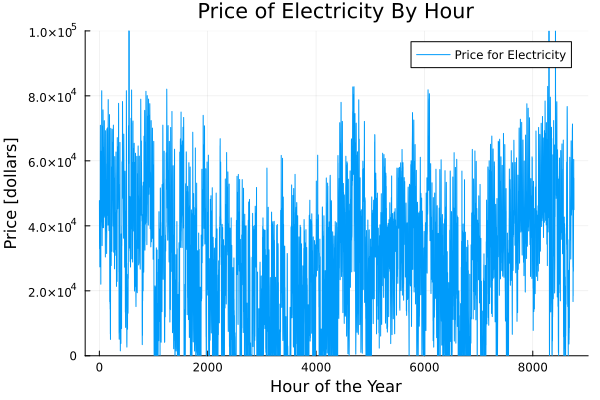

In [12]:
#electricity price per hour plot

NSEnew = value.(NSE).data
eprice = zeros(length(T))
for t in T
    eprice[t] = sum(gens[G, :VarCost] .* ynew[G, t]) + NSECost * NSEnew[t]
end

#plot eprice versus time
plot(T, eprice, ylim=(0,1*10^5), label="Price for Electricity", title="Price of Electricity By Hour")
xlabel!("Hour of the Year")
ylabel!("Price [dollars]")

### Problem 2 Write up

To set up the problem, the objectives and constraints, written in words, are as follows:

Objective: minimize the total cost for installation (fixed costs) and generation (variable costs), while accounting for the purchase of nonserved energy. 

$\Sigma Fixed Costs + \Sigma Variable Costs + Cost NSE * NSE$

Constraints: nonnegativity, in addition to

$Amount Generated >= Demand$ at all times

$Amount Generated by each plant <= Maximum Capacity$ at all times

$Geothermal Generated = 0.85*(Maximum Capacity)$

$Solar/Wind Generated = (Variable Capacity Factor)*(Maximum Capacity)$ for each time

The cost for nonserved energy is set to $10000. 


The results of the optimization are:

- installaed capacity should be approximately 1563.437 MW for NG CCGT, 900.001 MW for NG CT, 576.627 MW for wind, and 2042.574 MW for solar.

- total cost is $651.36 billion

- total nonserved energy is approximately 350 MW.

The fraction of annual generation for each plant is approximately:

- NG CCGT: 0.5039

- NG CT: 0.0279

- Wind: 0.1058

- Solar: 0.3624

Compared to the built generation capacity or maximum capacity, these fractions are reasonable. In general, plants that are used more often (larger fraction) were built with a greater maximum capacity. An interesting thing to note is the NG CT has a larger maximum capacity than wind, but wind generates a larger fraction of the annual electricity. Also, solar has the largest maximum capacity, but still generates a smaller fraction compared to NG CCGT, likely because solar cannot be used during nighttime hours and is less effective during the winter.

From the graph of price at each hour, we can see that although the price fluctuates greatly (since it's by hour, there's probably more electricity being used during the day or evening for lighting), prices are usually higher on the edges of the graph (during the winter) compared to the middle (during the summer). This can be because renewables like solar are more available in the summer and able to generate more of the electricity at no additional cost. 



### Problem 3 (10 points)

**This problem is only required for students in BEE 5750**.

The NY state legislature is considering enacting an annual
CO<sub>2</sub> limit, which for the utility would limit the emissions in
its footprint to 1.5 MtCO<sub>2</sub>/yr.

**In this problem**:

-   Reformulate your linear program from Problem 2 with any necessary
    changes to capture the CO<sub>2</sub> limit.
-   Implement the new optimization problem and find the optimal
    solution. How much should the utility build of each type of
    generating plant? What is different from your plan from Problem 1?
    Do these changes make sense?
-   What would the value to the utility be of allowing it to emit an
    additional 1000 tCO<sub>2</sub>/yr? An additional 5000?

## References

List any external references consulted, including classmates.